In [2]:
# ==========================================
# CELL 1: IMPORTS
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as scp
import pandas as pd
import time
import os

# Optional: Print working directory to ensure outputs save correctly
print(f"Current Working Directory: {os.getcwd()}")

Current Working Directory: c:\Users\coenw\OneDrive\Documenten\GitHub\numerical-methods-Coen


In [3]:
# ==========================================
# CELL 2: MOORING SYSTEM LOOKUP TABLE
# ==========================================
# The mooring offsets that converged to the specified horizontal forces.
mooring_offset = np.array([
    0, 3.49,  7.28, 10.15, 12.31, 13.9, 15.12, 16.23, 17.15, 17.98,
    18.74, 19.5, 20.22, 20.89, 21.54, 22.19, 22.85, 23.5, 24.13,
    24.75, 25.38, 25.97, 26.59, 27.22, 27.84, 28.44, 29.05, 29.67,
    30.25, 30.86, 31.48
])

# Fx, Fz components on left, right hand sides (from your provided tables)
mooring_table = np.array([
    [-301446.60, -349797.48, -410631.37, -470825.79, -556149.09, -645566.18, -734675.91, -833331.58, -927824.59, -1022160.27, -1115123.41, -1213381.04, -1310492.89, -1403732.66, -1496351.12, -1590714.92, -1687995.05, -1784986.08, -1879919.14, -1974086.30, -2070403.15, -2161091.87, -2256823.13, -2354484.90, -2450921.91, -2544512.82, -2639895.02, -2737049.16, -2828101.84, -2924017.01, -3021646.51],
    [-2687887.68, -3004799.94, -3527369.94, -4198179.18, -4958975.40, -5756274.47, -6550832.95, -7430509.03, -8273068.15, -9114224.45, -9943142.33, -10819269.21, -11685179.61, -12516564.08, -13342408.64, -14183815.66, -15051226.55, -15916059.56, -16762542.50, -17602196.23, -18461017.86, -19269655.60, -20123255.79, -20994069.56, -21853962.69, -22688478.16, -23538965.89, -24405253.32, -25217136.37, -26072376.43, -26942902.48],
    [315260.63,  240340.22,  210548.57,  185368.97,  164951.50,  158680.01,  146983.87,  145386.55,  140036.26,  131021.36,  128771.53,  128483.45,  126479.43,  122553.74,  115161.93,  113569.01,  113591.64,  112059.31,  108700.09,  107329.48,  106005.16,   99718.59,   98526.42,   95561.12,   94435.99,   94568.53,   93484.57,   92433.89,   86963.23,   86009.09,   83442.96],
    [-2693198.75, -2396810.98, -2140844.16, -1975535.70, -1865967.23, -1789537.39, -1736371.80, -1688767.71, -1651371.05, -1619547.19, -1591737.18, -1562691.06, -1538317.03, -1514335.98, -1492701.74, -1472054.66, -1449827.49, -1430269.62, -1410625.81, -1392839.12, -1375653.03, -1358563.91, -1342321.89, -1324478.49, -1308884.19, -1292147.63, -1277336.79, -1262980.69, -1248574.86, -1234875.69, -1219926.43]
])

# Normalize the Z forces relative to the initial resting state
mooring_table[1] -= mooring_table[1][0]
mooring_table[3] -= mooring_table[3][0]

def Fmoor(x):
    """Interpolates the mooring lookup table to find exact forces for a given displacement."""
    fxl = np.interp(x, mooring_offset, mooring_table[0])
    fzl = np.interp(x, mooring_offset, mooring_table[1])
    fxr = np.interp(x, mooring_offset, mooring_table[2])
    fzr = np.interp(x, mooring_offset, mooring_table[3])
    return fxl, fzl, fxr, fzr

In [4]:
# ==========================================
# CELL 3: SPAR GEOMETRY & PROPERTIES
# ==========================================
# 1. Geometric Properties
L = 130.0               # Total length of the spar [m]
D_upper = 6.5           # Platform Diameter Above Taper [m]
D_lower = 9.4           # Platform Diameter Below Taper [m]
x_taper_bottom = 108.0  # Position of the bottom of the taper (z=-12m) [m]
x_taper_top = 116.0     # Position of the top of the taper (z=-4m) [m]
t_wall = 0.0418         # Equivalent Uniform Wall Thickness [m]

def get_diameter(x):
    """Returns outer diameter at position x [m] from base."""
    xp = [0, x_taper_bottom, x_taper_top, L]
    fp = [D_lower, D_lower, D_upper, D_upper]
    return np.interp(x, xp, fp)

def get_inner_diameter(x):
    return get_diameter(x) - 2 * t_wall

def get_area(x):
    return (np.pi / 4) * (get_diameter(x)**2 - get_inner_diameter(x)**2)

def get_second_moment_of_area(x):
    return (np.pi / 64) * (get_diameter(x)**4 - get_inner_diameter(x)**4)

# 2. Material and Mass Properties
E = 210e9               # Young's Modulus for steel [Pa]
rho_steel = 8500.0      # Steel Density including paint/welds [kg/m^3]
total_mass = 7466330.0  # Target OC3 Platform Mass (Including Ballast) [kg]

# Integrate steel mass over the length
steel_mass = scp.quad(lambda x: rho_steel * get_area(x), 0, L)[0]
ballast_mass = total_mass - steel_mass

print(f"Computed Steel Mass:  {steel_mass:,.2f} kg")
print(f"Required Ballast Mass: {ballast_mass:,.2f} kg")

Computed Steel Mass:  1,299,674.49 kg
Required Ballast Mass: 6,166,655.51 kg


In [5]:
# ==========================================
# CELL 4: FEM SHAPE FUNCTIONS
# ==========================================
ne = 130        # Number of elements (1 element per meter)
nn = ne + 1     # Number of nodes
ndofs = 2 * nn  # Degrees of freedom (Translation + Rotation per node)
h = L / ne      # Length of each element [m]
xn = np.linspace(0, L, nn)

# Define element to DOF mapping
elem_dofs = [np.arange(2*ie, 2*ie + 4) for ie in range(ne)]

# Build Hermite Polynomials
matrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [1, h, h**2, h**3], [0, 1, 2*h, 3*h**2]])

def base(x): return np.array([[1], [x], [x**2], [x**3]]) if isinstance(x, float) else np.array([[np.ones(len(x))], [x], [x**2], [x**3]])
def dbase(x): return np.array([[0], [1], [2*x], [3*x**2]]) if isinstance(x, float) else np.array([[np.zeros(len(x))], [np.ones(len(x))], [2*x], [3*x**2]])
def ddbase(x): return np.array([[0], [0], [2], [6*x]]) if isinstance(x, float) else np.array([[np.zeros(len(x))], [np.zeros(len(x))], [2*np.ones(len(x))], [6*x]])

N_k, dN_k, ddN_k = [], [], []
for idof in range(4):
    rhs = np.zeros(4)
    rhs[idof] = 1
    coeff = np.linalg.solve(matrix, rhs)
    N_k.append(lambda x, c=coeff: np.dot(np.transpose(base(x)), c))
    dN_k.append(lambda x, c=coeff: np.dot(np.transpose(dbase(x)), c))
    ddN_k.append(lambda x, c=coeff: np.dot(np.transpose(ddbase(x)), c))

# Calculate Local Matrices via numerical integration
M_list, K_list = [], []
for ie in range(ne):
    x_start = xn[ie]
    M_k, K_k = np.zeros((4, 4)), np.zeros((4, 4))
    
    for idof in range(4):
        for jdof in range(4):
            M_k[idof, jdof] = scp.quad(lambda lx: rho_steel * get_area(x_start + lx) * N_k[idof](lx) * N_k[jdof](lx), 0, h)[0]
            K_k[idof, jdof] = scp.quad(lambda lx: E * get_second_moment_of_area(x_start + lx) * ddN_k[idof](lx) * ddN_k[jdof](lx), 0, h)[0]
    
    M_list.append(M_k)
    K_list.append(K_k)

print(f"Successfully calculated {len(K_list)} element matrices.")

Successfully calculated 130 element matrices.


In [6]:
# ==========================================
# CELL 5: GLOBAL ASSEMBLY & BALLAST CG
# ==========================================
M_global = np.zeros((ndofs, ndofs))
K_global = np.zeros((ndofs, ndofs))

# Assemble steel shell matrices
for ie in range(ne):
    dofs = elem_dofs[ie]
    M_global[np.ix_(dofs, dofs)] += M_list[ie]
    K_global[np.ix_(dofs, dofs)] += K_list[ie]

# --- CG Balancing for Ballast ---
target_z_cg = -89.9155
target_x_cg = 120.0 + target_z_cg  # Distance from the spar base

# Baseline steel mass moments
m_nodes = np.array([np.sum(M_global[2*i, ::2]) for i in range(nn)])
steel_moment = np.sum(m_nodes * xn)

# Required ballast to hit target CG
req_ballast_moment = (total_mass * target_x_cg) - steel_moment
H_fill = 2.0 * (req_ballast_moment / ballast_mass)
density_ballast = ballast_mass / H_fill

# Distribute ballast mass
for i in range(nn):
    x = xn[i]
    x_start = max(0.0, x - h/2.0)
    x_end = min(H_fill, x + h/2.0)
    
    if x_start < x_end:
        node_ballast = density_ballast * (x_end - x_start)
        M_global[2*i, 2*i] += node_ballast # Add to translational DOF
        m_nodes[i] += node_ballast         # Update tracker

# Verification check
cg_calc = np.sum(m_nodes * (xn - 120.0)) / np.sum(m_nodes)
print(f"Target CG:      z = {target_z_cg:.4f} m")
print(f"Calculated CG:  z = {cg_calc:.4f} m")
print(f"Ballast Fill Height: {H_fill:.2f} m from base")

Target CG:      z = -89.9155 m
Calculated CG:  z = -89.9177 m
Ballast Fill Height: 46.51 m from base


In [7]:
# ==========================================
# CELL 6: HYDRODYNAMICS & RNA MASS
# ==========================================
rho_water = 1025.0 # Seawater Density [kg/m^3]
C_a = 1.0          # Constant Added Mass Coefficient

# 1. Added Mass (Nodes 0 to 120 are submerged)
for i_node in range(121): 
    x_node = xn[i_node]
    L_tributary = (h / 2.0) if (i_node == 0 or i_node == 120) else h
    displaced_mass = rho_water * ((np.pi / 4) * get_diameter(x_node)**2) * L_tributary
    M_global[2*i_node, 2*i_node] += (C_a * displaced_mass)

# 2. Hydrostatic Restoring Stiffness
g = 9.81
node_swL = 120
A_waterplane = (np.pi / 4) * get_diameter(xn[node_swL])**2

C33_heave = rho_water * g * A_waterplane
C55_pitch = 4.11e9  # [N-m/rad]

K_global[2*node_swL, 2*node_swL] += C33_heave
K_global[2*node_swL + 1, 2*node_swL + 1] += C55_pitch

# 3. RNA (Rotor-Nacelle Assembly) Point Mass
m_RNA = 350000.0   # kg (Check exact value for your turbine)
node_top = 130
M_global[2*node_top, 2*node_top] += m_RNA

In [8]:
# ==========================================
# CELL 7: WAVE KINEMATICS & MOORING FORCES
# ==========================================
wave_amplitude = 1.0  # Wave height [m]
wave_period = 8.0     # Wave period [s]
wave_freq = 2 * np.pi / wave_period  

# Pre-calculate spatial wave geometry outside the time-loop for speed
k_wave = wave_freq**2 / 9.81
wave_areas = np.zeros(121)
depth_decays = np.zeros(121)
L_tribs = np.zeros(121)

for i_node in range(121):
    x_node = xn[i_node]
    z_node = x_node - 120.0
    wave_areas[i_node] = (np.pi / 4) * get_diameter(x_node)**2
    depth_decays[i_node] = np.exp(k_wave * z_node)
    L_tribs[i_node] = (h / 2.0) if (i_node == 0 or i_node == 120) else h

def compute_wave_loading(t):
    """Vectorized calculation of horizontal wave inertia forces."""
    F_wave = np.zeros(ndofs)
    surface_accel = wave_amplitude * wave_freq**2 * np.cos(wave_freq * t)
    F_horizontal = rho_water * wave_areas * (surface_accel * depth_decays) * L_tribs
    F_wave[0:242:2] += F_horizontal 
    return F_wave

mooring_node = 50 # Fairleads attached at x = 50m (z = -70m)
def compute_mooring_forces(u_mooring):
    """Calculates non-linear symmetric restoring force from mooring tables."""
    F_mooring = np.zeros(ndofs)
    offset = np.abs(u_mooring)
    fxl, fzl, fxr, fzr = Fmoor(offset)
    net_Fx = fxl + fxr 
    
    if u_mooring < 0: 
        net_Fx = -net_Fx # Flip direction if swaying backward
        
    F_mooring[2*mooring_node] = net_Fx
    return F_mooring

In [9]:
# ==========================================
# CELL 8: STATE-SPACE & EXACT JACOBIAN
# ==========================================
# Rayleigh Structural Damping
alpha_damp = 0.05 
beta_damp = 0.02
C_global = alpha_damp * M_global + beta_damp * K_global

# Initial Conditions (At rest)
y0 = np.concatenate([np.zeros(ndofs), np.zeros(ndofs)])

# Precompute M inverse for extreme speed in the loop
M_inv = np.linalg.inv(M_global) 

def odefun(t, y):
    """The State-Space derivative function."""
    u = y[:ndofs]
    v = y[ndofs:]

    F_total = compute_wave_loading(t) + compute_mooring_forces(u[2*mooring_node])
    
    damping_force = np.dot(C_global, v)
    stiffness_force = np.dot(K_global, u)
    
    u_dd = np.dot(M_inv, (F_total - damping_force - stiffness_force))
    return np.concatenate([v, u_dd])

# --- PRE-COMPUTE THE EXACT LINEAR JACOBIAN MATRIX ---
print("Assembling analytical Jacobian to accelerate BDF solver...")
I_mat = np.eye(ndofs)
Z_mat = np.zeros((ndofs, ndofs))
J_top = np.hstack((Z_mat, I_mat))
J_bot = np.hstack((-np.dot(M_inv, K_global), -np.dot(M_inv, C_global)))
Jacobian_matrix = np.vstack((J_top, J_bot))

Assembling analytical Jacobian to accelerate BDF solver...


Solving time-domain dynamics (Please wait)...
Simulation completed in 0.57 seconds.
Solver success: True


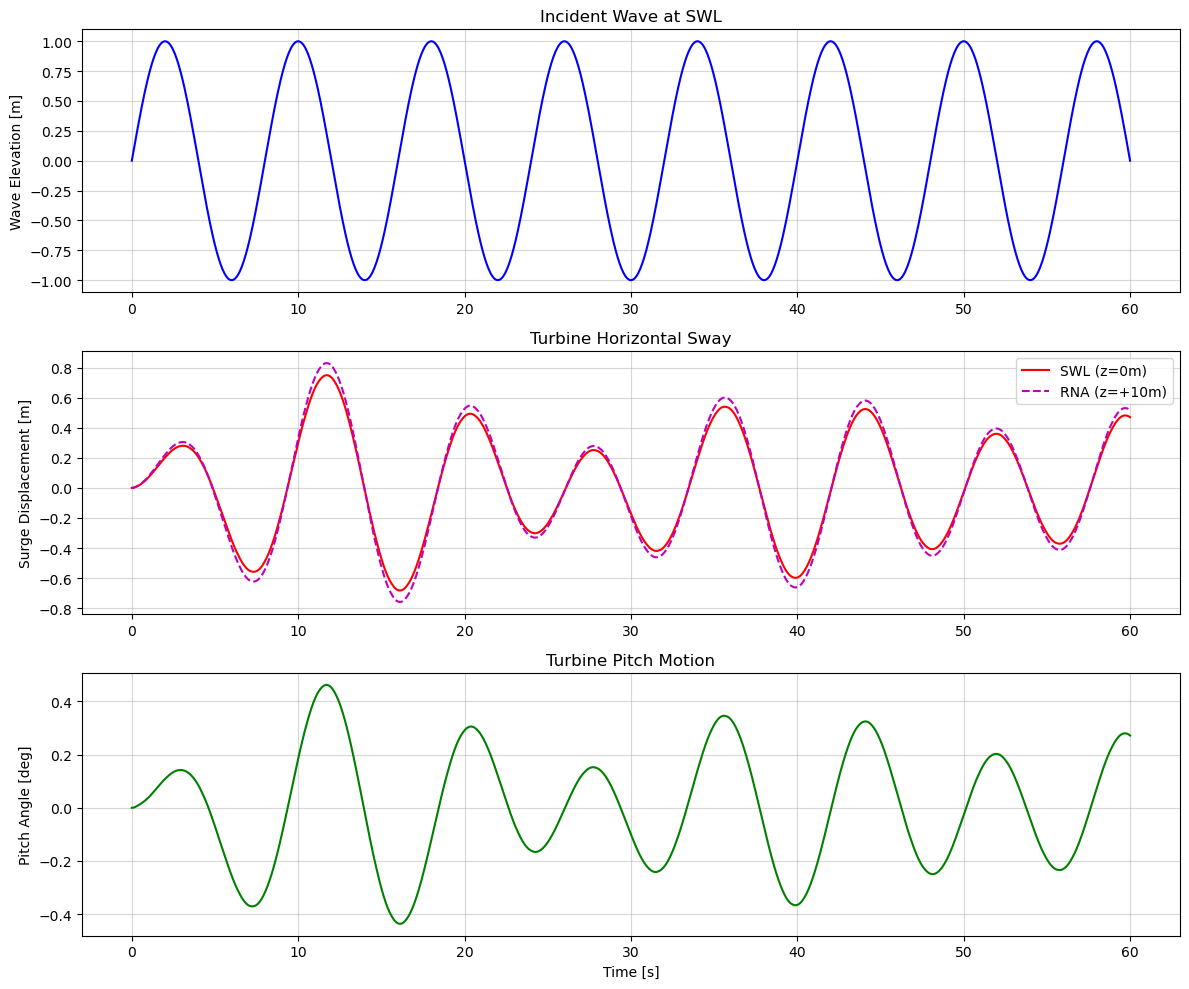

In [10]:
# ==========================================
# CELL 9: SOLVE AND PLOT RESULTS
# ==========================================
t_final = 60.0  # Simulate 60 seconds
n_steps = 1000
t_eval = np.linspace(0, t_final, n_steps)

print("Solving time-domain dynamics (Please wait)...")
start_time = time.time()

sol = scp.solve_ivp(
    odefun, 
    [t_eval[0], t_eval[-1]], 
    y0, 
    t_eval=t_eval, 
    method='BDF', 
    jac=Jacobian_matrix,
    rtol=1e-2,
    atol=1e-3
)

print(f"Simulation completed in {time.time() - start_time:.2f} seconds.")
print(f"Solver success: {sol.status == 0}")

# Extract results
u_sol = sol.y[:ndofs, :]

# Plot wave surface elevation and spar response
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# 1. Incident Wave
axes[0].plot(sol.t, wave_amplitude * np.sin(wave_freq * sol.t), 'b-', linewidth=1.5)
axes[0].set_ylabel('Wave Elevation [m]')
axes[0].set_title('Incident Wave at SWL')
axes[0].grid(True, alpha=0.5)

# 2. Surge Motion at SWL (Node 120) and Top RNA (Node 130)
axes[1].plot(sol.t, u_sol[2 * node_swL, :], 'r-', label='SWL (z=0m)')
axes[1].plot(sol.t, u_sol[2 * 130, :], 'm--', label='RNA (z=+10m)')
axes[1].set_ylabel('Surge Displacement [m]')
axes[1].set_title('Turbine Horizontal Sway')
axes[1].legend()
axes[1].grid(True, alpha=0.5)

# 3. Pitch Rotation at SWL
axes[2].plot(sol.t, np.degrees(u_sol[2 * node_swL + 1, :]), 'g-', linewidth=1.5)
axes[2].set_ylabel('Pitch Angle [deg]')
axes[2].set_xlabel('Time [s]')
axes[2].set_title('Turbine Pitch Motion')
axes[2].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()